In [947]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [948]:
dframe = pd.read_csv("insurance.csv", delimiter=',')

In [949]:
dframe

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [950]:
dframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Нулевые данные отсутсвуют

Для начала построим гистограммы для рассмотрения распределения данных

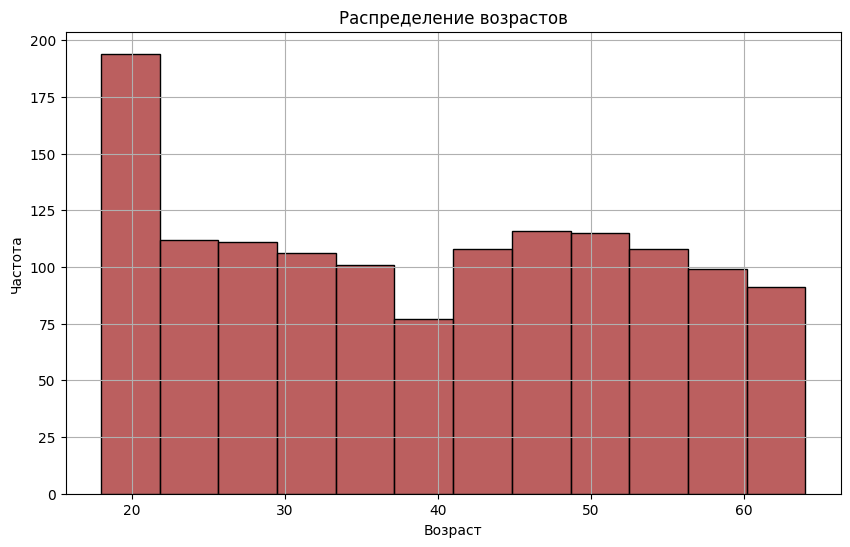

In [951]:
plt.figure(figsize=(10, 6))
sns.histplot(data=dframe, x='age', kde=False, color='brown')  
plt.title('Распределение возрастов')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.grid()
plt.show()

Видим большое количество молодых людей. Если исключить этот столбец, распределение будет напоминать равномерное.

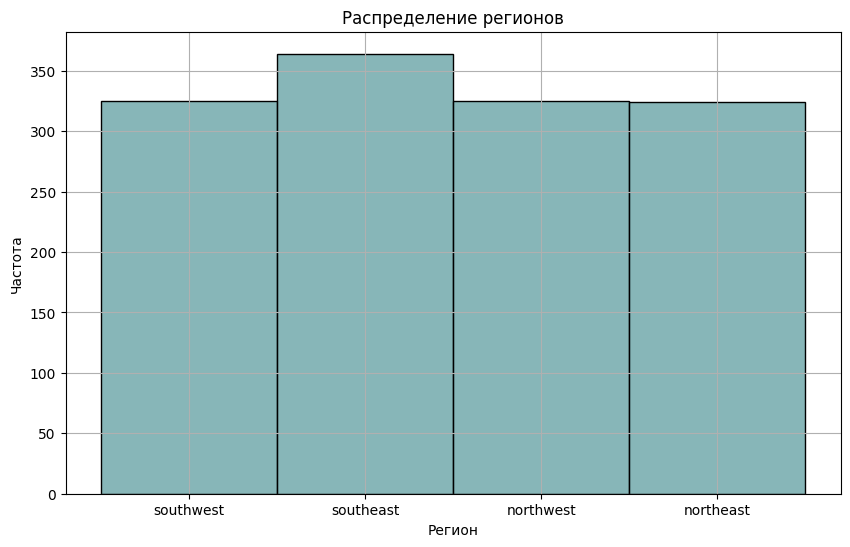

In [952]:
plt.figure(figsize=(10, 6))
sns.histplot(data=dframe, x='region', kde=False, color='cadetblue')  
plt.title('Распределение регионов')
plt.xlabel('Регион')
plt.ylabel('Частота')
plt.grid()
plt.show()

По регионам распредление тоже более-менее равномерное

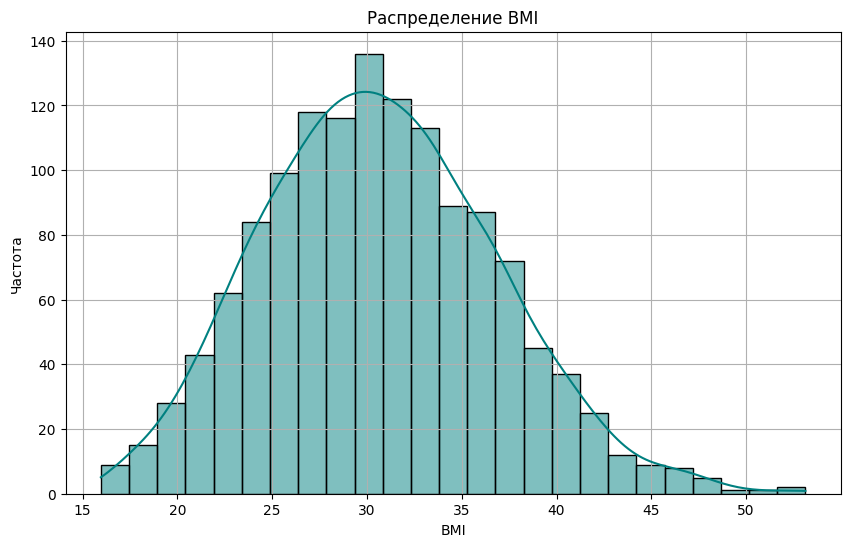

In [953]:
plt.figure(figsize=(10, 6))
sns.histplot(data=dframe, x='bmi', bins=25, kde=True, color='teal')  
plt.title('Распределение BMI')
plt.xlabel('BMI')
plt.ylabel('Частота')
plt.grid()
plt.show()

Распредление !напоминает! нормальное. Можно заметить, что мода равна 30, хотя при этом нормальное ИМТ не более 25.

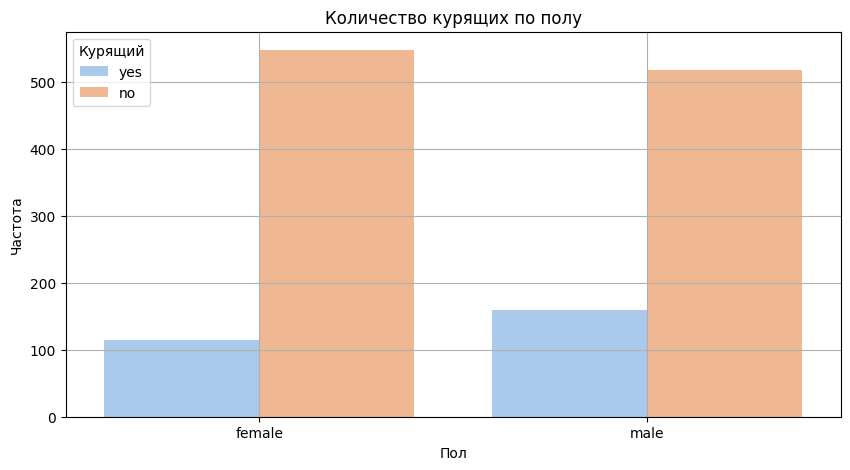

In [954]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=dframe,
    x='sex',
    hue='smoker',
    palette='pastel'
)
plt.title('Количество курящих по полу')
plt.xlabel('Пол')
plt.ylabel('Частота')
plt.legend(title='Курящий')
plt.grid()
plt.show()

Видим, что мужчины курят чуть чаще.

Предобработаем данные для построения heatmap

In [955]:
LE_arr = ['sex', 'smoker']
OHE_arr = ['region']
print("Label Encoder:", LE_arr)
print("One Hot Encoder:", OHE_arr)

Label Encoder: ['sex', 'smoker']
One Hot Encoder: ['region']


In [956]:
dframe2 = dframe.copy()
for obj in LE_arr:
    dframe2[obj] = LabelEncoder().fit_transform(dframe2[obj])
dframe2 = pd.get_dummies(dframe2, columns=OHE_arr, dtype = int)
dframe2

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


Корреляционную матрицу будем строить с учетом OHE столбцов. Важно понимать, что корреляция между непрерывной переменной и OHE-переменной показывает, как среднее значение непрерывной переменной отличается для каждого вида объекта (столбца). В данном случае виды объекта это регионы. 

<Axes: >

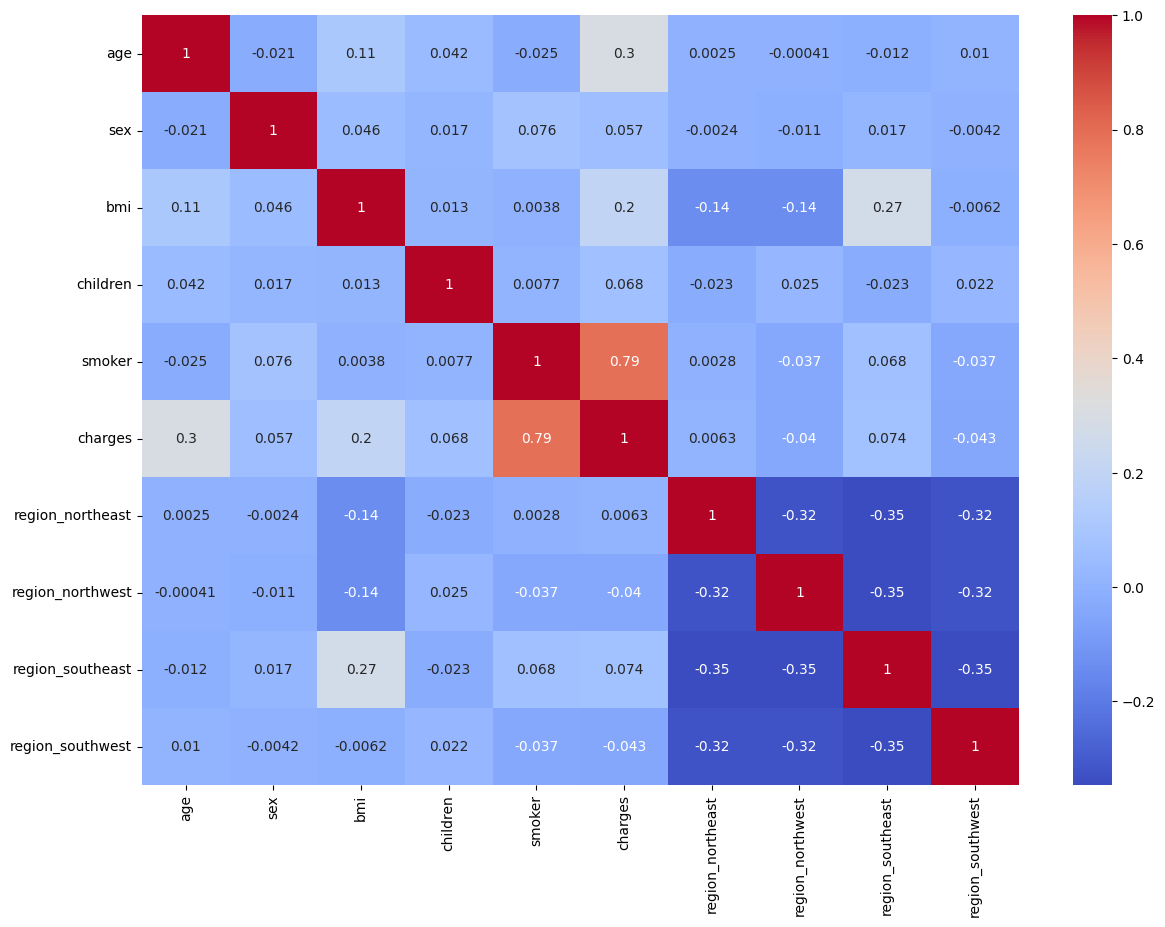

In [957]:
corr_matrix = dframe2.corr()
plt.figure(figsize = (10 * 2**0.5,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt = '.2g')

# Обсудим корреляцию:
- Если обсуждать затраты, то самая сильная корреляция между затратами и:
1. Курением. Коэффициент корреляции достигает 0.79!
2. Возрастом. Корреляция достигает 0.3, то есть чем выше возраст, тем больше затраты на медицину. 
3. ИМТ. Индекс массы телы также коррелирует с затратами, но с еще меньшим коэффициентом - 0.2.\
Остальные переменные не показывают такой корреляции с затратами (Меньше 10 процентов по модулю)
- Если говорить о других переменных, то стоит рассмотреть корреляцию между BMI и:
1. Проживанием на юго-востоке США - корреляция достигает 27%.
2. Возрастом. Корреляция не такая большая, всего 0.11, но по сравнению с другими переменными это много.

Интересно, что на юго-западе США и правда есть проблема с ожирением, то есть данные подтверждаются другими:



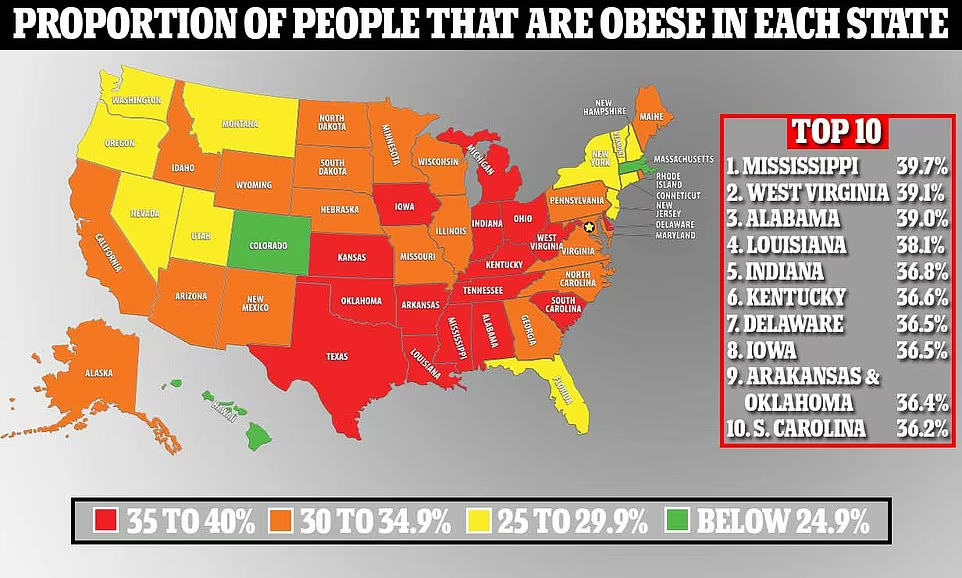

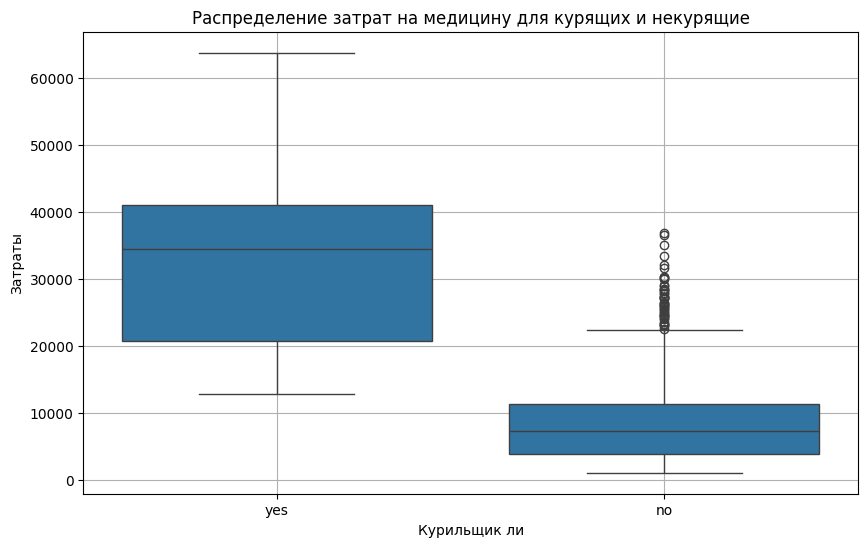

In [958]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=dframe, x="smoker", y="charges")
plt.grid()
plt.title("Распределение затрат на медицину для курящих и некурящие")
plt.xlabel('Курильщик ли')
plt.ylabel('Затраты')
plt.show()

Видно, что курильщики заметно больше денег тратят на медицину. Кроме того, заметен и бОльший разброс в затратах.

In [959]:
dframe_bmi = dframe.copy() 

dframe_bmi.loc[dframe['bmi'] >= 30, 'bmi'] = 'obesity'
dframe_bmi.loc[(dframe['bmi'] < 30) & (dframe['bmi'] >= 25), 'bmi'] = 'overweight'
dframe_bmi.loc[(dframe['bmi'] < 25) & (dframe['bmi'] >= 19), 'bmi'] = 'normal weight'
dframe_bmi.loc[dframe['bmi'] < 19, 'bmi'] = 'underweight'

C:\Users\Terol19\AppData\Local\Temp\ipykernel_24012\2249504808.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'obesity' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dframe_bmi.loc[dframe['bmi'] >= 30, 'bmi'] = 'obesity'


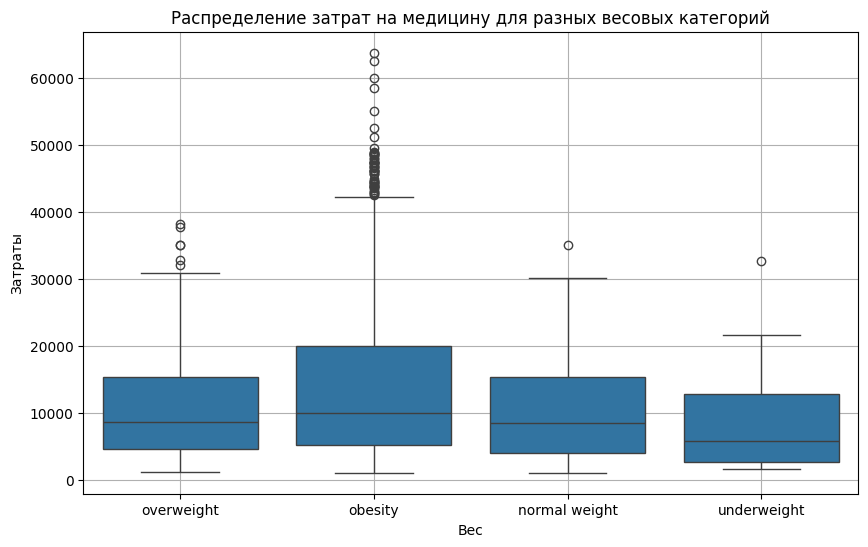

In [960]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=dframe_bmi, x="bmi", y="charges")
plt.grid()
plt.title("Распределение затрат на медицину для разных весовых категорий")
plt.xlabel('Вес')
plt.ylabel('Затраты')
plt.show()

Люди с ожирением тратят больше денег на медицину, также в этой выборке больше дисперсия и большее число выбросов. Интересно, что низкий ИМТ (ниже нормы) не повышает затраты, а понижает.